In [67]:
import fastf1
import pandas as pd
import statsmodels.formula.api as smf
import time
import os

# ============================================================
# Setup (run once at the top of your notebook/script)
# ============================================================

CACHE_DIR = './f1_cache'
DATA_FILE = '../data/all_laps.parquet'

os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)
fastf1.set_log_level('ERROR')


# ============================================================
# Data loading and cleaning
# ============================================================

def clean_laps(df):
    """Filter out non-representative laps."""
    df = df.copy()
    df["LapTime"] = df["LapTime"].dt.total_seconds()
    
    mask = (
        (df["LapNumber"] > 1)
        & (df["TrackStatus"] == "1")
        & (df["PitInTime"].isna())
        & (df["PitOutTime"].isna())
        & (df["LapTime"].notna())
    )
    df = df[mask]
    
    if len(df) == 0:
        return df
    
    med = df["LapTime"].median()
    df = df[df["LapTime"] < 1.1 * med]
    return df


def load_clean_race(year, event):
    session = fastf1.get_session(year, event, 'R')
    session.load()
    laps = session.laps[
        ["Driver", "Team", "LapTime", "LapNumber", "Stint", "Compound",
         "TyreLife", "TrackStatus", "PitInTime", "PitOutTime"]
    ].copy()
    laps = clean_laps(laps)
    if len(laps) == 0:
        return laps
    laps = laps.copy()  # <-- add this line
    laps["Year"] = year
    laps["Race"] = event
    laps["RaceID"] = f"{year}_{event}"
    return laps


def load_all_seasons(years, save_path=DATA_FILE, sleep_seconds=1):
    """Load all races across given years, saving incrementally to disk."""
    # Resume from existing file if present
    if os.path.exists(save_path):
        existing = pd.read_parquet(save_path)
        loaded_keys = set(existing["RaceID"].unique())
        all_laps = [existing]
        print(f"Resuming from {save_path}: {len(loaded_keys)} races already loaded")
    else:
        loaded_keys = set()
        all_laps = []
    
    for year in years:
        try:
            schedule = fastf1.get_event_schedule(year, include_testing=False)
        except Exception as e:
            print(f"Failed to get schedule for {year}: {e}")
            continue
        
        for event in schedule["EventName"].tolist():
            race_id = f"{year}_{event}"
            if race_id in loaded_keys:
                continue
            try:
                laps = load_clean_race(year, event)
                if len(laps) > 0:
                    all_laps.append(laps)
                    loaded_keys.add(race_id)
                    # Save after each successful race
                    pd.concat(all_laps, ignore_index=True).to_parquet(save_path)
                    print(f"Loaded {race_id} ({len(laps)} laps)")
            except Exception as e:
                print(f"Failed {race_id}: {e}")
                # If it's a rate limit, stop early so user can resume later
                if "RateLimit" in str(type(e).__name__) or "500 calls" in str(e):
                    print("Rate limit hit. Stop here and resume later.")
                    return pd.concat(all_laps, ignore_index=True)
                continue
            time.sleep(sleep_seconds)
    
    return pd.concat(all_laps, ignore_index=True)


# ============================================================
# Lineup construction
# ============================================================

def build_lineups(df):
    """Assign lineup_id splitting on driver-pair changes within team-season."""
    if len(df) == 0:
        return df
    
    df = df.copy().sort_values(["Team", "Year", "RaceID"])
    
    def assign_phases(team_season_df):
        race_drivers = (
            team_season_df.groupby("RaceID")["Driver"]
            .apply(lambda x: tuple(sorted(x.unique())))
        )
        phases = {}
        current_phase = "A"
        prev_pair = None
        for race_id, pair in race_drivers.items():
            if prev_pair is not None and pair != prev_pair:
                current_phase = chr(ord(current_phase) + 1)
            phases[race_id] = current_phase
            prev_pair = pair
        team_season_df = team_season_df.copy()
        team_season_df["lineup_phase"] = team_season_df["RaceID"].map(phases)
        return team_season_df
    
    df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)
    df["lineup_id"] = (
        df["Team"].astype(str) + "_" + df["Year"].astype(str) + "_" + df["lineup_phase"]
    )
    return df


def assign_driver_indicator(df):
    """Within each lineup, assign IsDriver2 (alphabetically second driver)."""
    def _assign(group):
        drivers_sorted = sorted(group["Driver"].unique())
        if len(drivers_sorted) < 2:
            group = group.copy()
            group["IsDriver2"] = 0
            group["Driver1"] = drivers_sorted[0] if drivers_sorted else None
            group["Driver2"] = None
            return group
        d1, d2 = drivers_sorted[0], drivers_sorted[1]
        group = group.copy()
        group["IsDriver2"] = (group["Driver"] == d2).astype(int)
        group["Driver1"] = d1
        group["Driver2"] = d2
        return group
    
    return df.groupby("lineup_id", group_keys=False).apply(_assign)


def filter_for_analysis(df, min_laps_per_driver=20, allowed_compounds=("SOFT", "MEDIUM", "HARD")):
    """Apply analysis-ready filters."""
    df = df[df["Compound"].isin(allowed_compounds)].copy()
    
    # For each (RaceID, Team) pair, check that BOTH drivers in that team have enough laps
    counts = df.groupby(["RaceID", "Team", "Driver"]).size().reset_index(name="n_laps")
    
    # For each (RaceID, Team), check the minimum lap count across drivers
    min_per_race_team = counts.groupby(["RaceID", "Team"])["n_laps"].min().reset_index()
    valid = min_per_race_team[min_per_race_team["n_laps"] >= min_laps_per_driver]
    
    # Keep only laps from valid (RaceID, Team) combos
    df = df.merge(valid[["RaceID", "Team"]], on=["RaceID", "Team"], how="inner")
    
    return df


# ============================================================
# Modelling
# ============================================================

def fit_lap_time_model(df):
    df = df.copy()
    cols_needed = ["LapTime", "TyreLife", "LapNumber", "Compound", "IsDriver2", "RaceID"]
    df = df.dropna(subset=cols_needed).reset_index(drop=True)
    
    model = smf.mixedlm(
        "LapTime ~ TyreLife + LapNumber + C(Compound) + IsDriver2",
        data=df,
        groups=df["RaceID"],
    ).fit()
    return model


def analyse_loaded_laps(laps, team_filter=None, min_races=3):
    """Run the full analysis pipeline on already-loaded laps."""
    if team_filter is not None:
        if isinstance(team_filter, str):
            team_filter = [team_filter]
        laps = laps[laps["Team"].isin(team_filter)].copy()
    
    if len(laps) == 0:
        print("No data after filtering")
        return None
    
    laps = build_lineups(laps)
    laps = assign_driver_indicator(laps)
    laps = filter_for_analysis(laps)
    
    if laps["lineup_id"].nunique() == 0:
        print("No valid lineups")
        return None
    
    results = {}
    for lineup_id, lineup_df in laps.groupby("lineup_id"):
        if lineup_df["Driver"].nunique() < 2:
            continue
        if lineup_df["RaceID"].nunique() < min_races:
            continue
        lineup_df = lineup_df.reset_index(drop=True)
        try:
            model = fit_lap_time_model(lineup_df)
            d1 = lineup_df["Driver1"].iloc[0]
            d2 = lineup_df["Driver2"].iloc[0]
            coef = model.params["IsDriver2"]
            se = model.bse["IsDriver2"]
            results[lineup_id] = {
                "Driver1": d1,
                "Driver2": d2,
                "n_obs": len(lineup_df),
                "n_races": lineup_df["RaceID"].nunique(),
                "gap_d2_minus_d1_sec": coef,
                "se": se,
                "ci_lower": coef - 1.96 * se,
                "ci_upper": coef + 1.96 * se,
                "model": model,
            }
        except Exception as e:
            print(f"Model failed for {lineup_id}: {e}")
            continue
    
    return results


def summarise_results(results):
    """Build a clean summary DataFrame from results dict."""
    summary = pd.DataFrame([
        {
            "lineup": lid,
            "d1": info["Driver1"],
            "d2": info["Driver2"],
            "gap": round(info["gap_d2_minus_d1_sec"], 3),
            "se": round(info["se"], 3),
            "ci_lower": round(info["ci_lower"], 3),
            "ci_upper": round(info["ci_upper"], 3),
            "n_races": info["n_races"],
            "n_laps": info["n_obs"],
        }
        for lid, info in results.items()
    ]).sort_values("lineup").reset_index(drop=True)
    return summary

In [9]:
laps_all = load_all_seasons(years=range(2018, 2026))

Resuming from all_laps.parquet: 172 races already loaded


In [11]:
laps_all = laps_all.reset_index(drop=True)
laps_all.to_parquet(DATA_FILE)

In [20]:
results_all = analyse_loaded_laps(laps_all)
print(summarise_results(results_all))

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)
/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:157: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lineup_id", group_keys=False).apply(_assign)


                       lineup   d1   d2    gap     se  ci_lower  ci_upper  \
0    Alfa Romeo Racing_2019_A  GIO  RAI -0.317  0.045    -0.404    -0.229   
1    Alfa Romeo Racing_2020_A  GIO  RAI -0.119  0.046    -0.210    -0.029   
2    Alfa Romeo Racing_2021_A  GIO  RAI -0.094  0.088    -0.267     0.079   
3    Alfa Romeo Racing_2021_C  GIO  RAI -0.123  0.128    -0.374     0.127   
4    Alfa Romeo Racing_2021_G  GIO  RAI -0.081  0.068    -0.215     0.052   
..                        ...  ...  ...    ...    ...       ...       ...   
131           Williams_2022_C  ALB  LAT  0.338  0.089     0.164     0.512   
132           Williams_2022_F  ALB  LAT  0.536  0.078     0.384     0.688   
133           Williams_2023_A  ALB  SAR  0.216  0.040     0.138     0.293   
134           Williams_2024_E  ALB  SAR  0.437  0.059     0.320     0.553   
135           Williams_2025_C  ALB  SAI -0.041  0.040    -0.120     0.038   

     n_races  n_laps  
0         19    1887  
1         14    1388  
2     

In [21]:
summary = summarise_results(results_all)
summary["team"] = summary["lineup"].str.rsplit("_", n=2).str[0]
summary["year"] = summary["lineup"].str.split("_").str[-2].astype(int)
summary["abs_gap"] = summary["gap"].abs()
summary["significant"] = (summary["ci_lower"] > 0) | (summary["ci_upper"] < 0)

# Filter to substantive lineups (avoid one-off comparisons)
clean = summary[summary["n_races"] >= 5].copy()
print(f"{len(clean)} of {len(summary)} lineups have ≥5 races")

98 of 136 lineups have ≥5 races


In [22]:
# A) Top teams across years — is the gap stable?
top_teams = ["Mercedes", "Ferrari", "Red Bull Racing", "McLaren"]
print("\n=== TOP TEAMS ===")
print(clean[clean["team"].isin(top_teams)]
      .sort_values(["team", "year"])
      [["lineup", "d1", "d2", "gap", "se", "n_races"]]
      .to_string(index=False))

# B) Distribution of absolute gaps
print("\n=== DISTRIBUTION ===")
print(clean["abs_gap"].describe())

# C) Largest and smallest
print("\n=== LARGEST GAPS ===")
print(clean.nlargest(10, "abs_gap")[["lineup", "d1", "d2", "gap", "se", "n_races"]].to_string(index=False))
print("\n=== MOST BALANCED ===")
print(clean.nsmallest(10, "abs_gap")[["lineup", "d1", "d2", "gap", "se", "n_races"]].to_string(index=False))


=== TOP TEAMS ===
                lineup  d1  d2    gap    se  n_races
        Ferrari_2018_A RAI VET  0.063 0.055       12
        Ferrari_2019_A LEC VET -0.108 0.039       18
        Ferrari_2020_A LEC VET  0.497 0.058       11
        Ferrari_2021_A LEC SAI  0.089 0.061        8
        Ferrari_2021_E LEC SAI  0.181 0.059        8
        Ferrari_2022_C LEC SAI -0.077 0.057        6
        Ferrari_2022_G LEC SAI  0.039 0.083        7
        Ferrari_2023_C LEC SAI  0.075 0.041       13
        Ferrari_2024_A LEC SAI  0.009 0.033       18
        Ferrari_2025_A HAM LEC -0.276 0.035       20
        McLaren_2018_C ALO VAN  0.165 0.074        9
        McLaren_2019_C NOR SAI -0.107 0.050       13
        McLaren_2020_C NOR SAI -0.206 0.059        6
        McLaren_2021_A NOR RIC  0.438 0.055        8
        McLaren_2021_C NOR RIC  0.365 0.051       11
        McLaren_2022_A NOR RIC  0.487 0.049       19
        McLaren_2023_C NOR PIA  0.223 0.046        6
        McLaren_2023_E NOR 

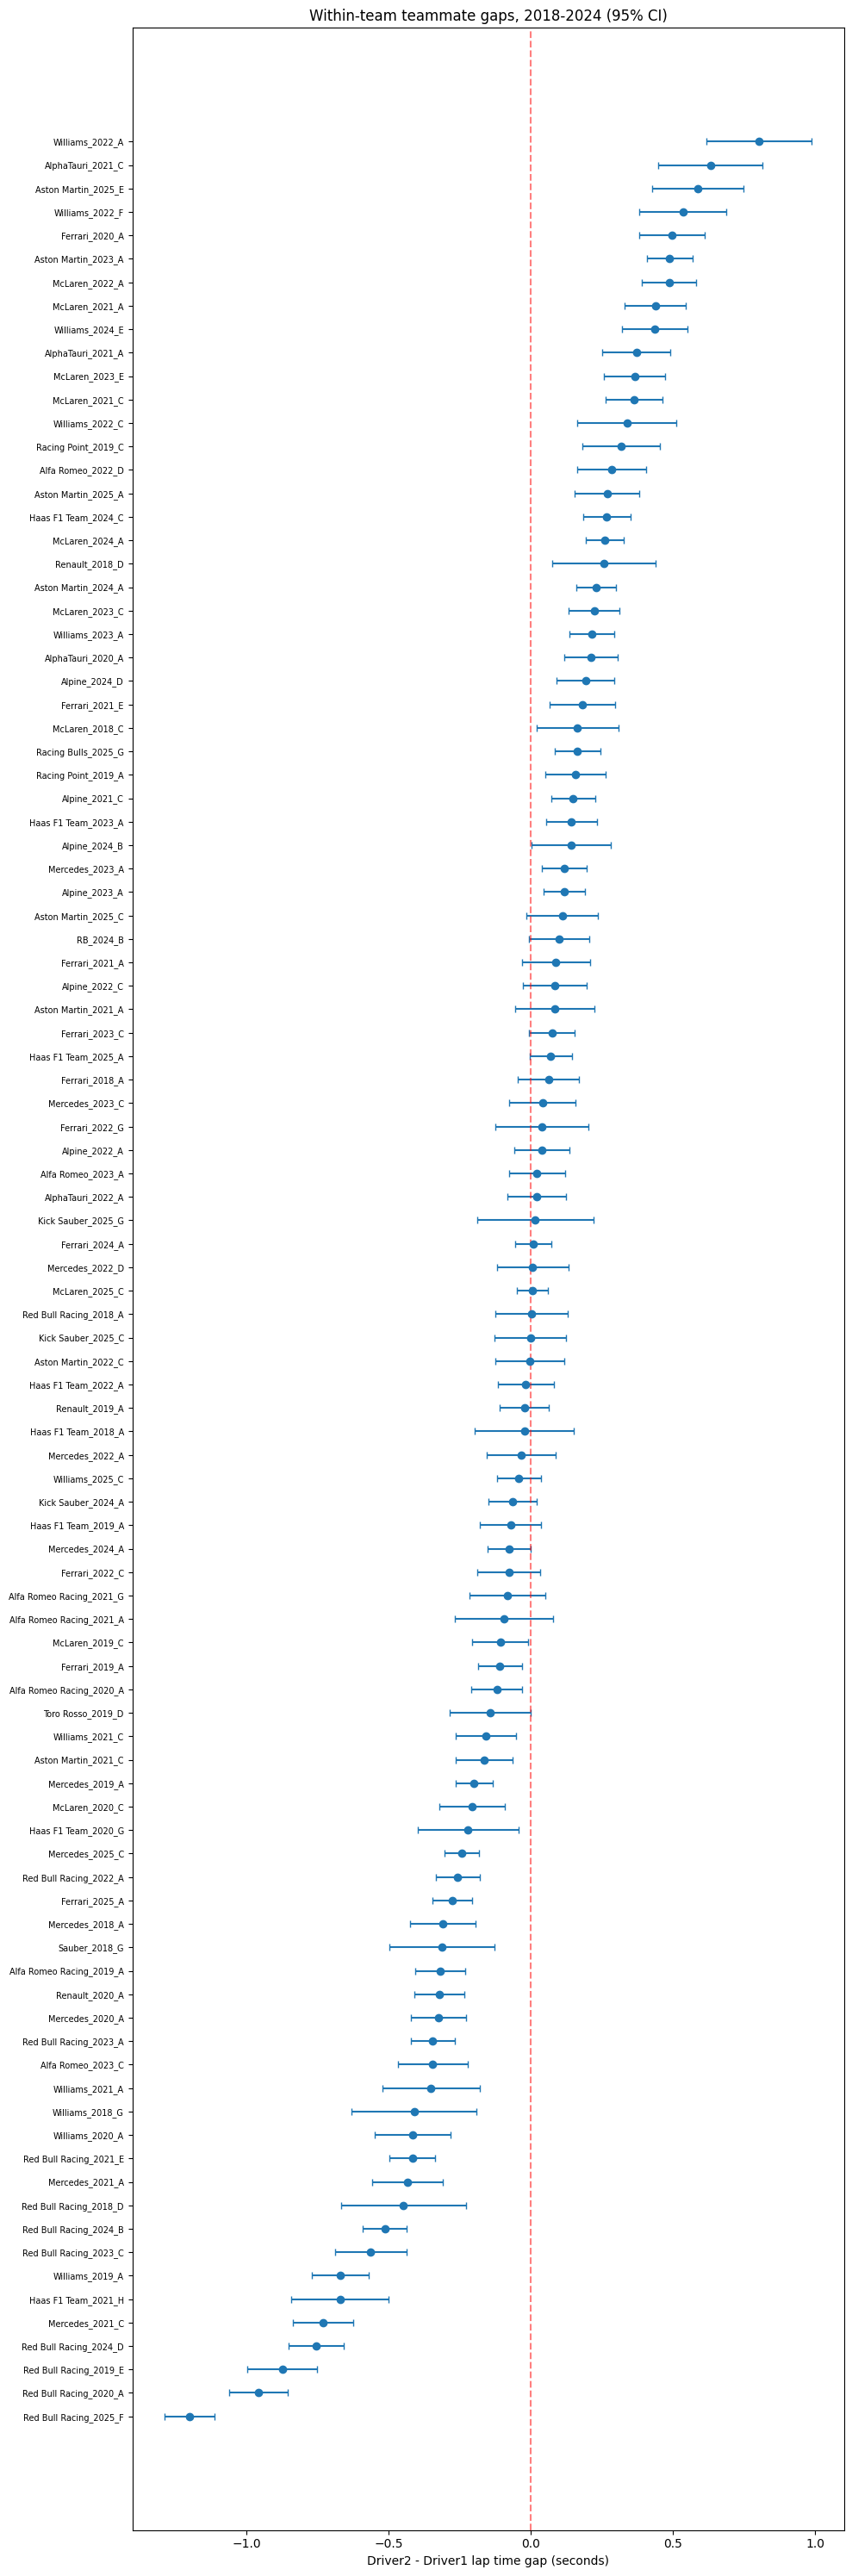

In [23]:
import matplotlib.pyplot as plt

clean_sorted = clean.sort_values("gap")
fig, ax = plt.subplots(figsize=(10, 30))
ax.errorbar(
    clean_sorted["gap"],
    range(len(clean_sorted)),
    xerr=1.96 * clean_sorted["se"],
    fmt='o',
    capsize=3,
)
ax.axvline(0, color='red', linestyle='--', alpha=0.5)
ax.set_yticks(range(len(clean_sorted)))
ax.set_yticklabels(clean_sorted["lineup"], fontsize=7)
ax.set_xlabel("Driver2 - Driver1 lap time gap (seconds)")
ax.set_title("Within-team teammate gaps, 2018-2024 (95% CI)")
plt.tight_layout()
plt.savefig("../images/teammate_gaps.png", dpi=150)
plt.show()

In [33]:
def anchor_driver_gaps(summary, driver, team=None):
    mask = (summary["d1"] == driver) | (summary["d2"] == driver)
    if team is not None:
        mask &= summary["team"] == team
    df = summary[mask].copy().sort_values("year")
    
    is_d2 = df["d2"] == driver
    sign = is_d2.map({True: 1, False: -1})
    
    df["anchor_gap"] = df["gap"] * sign
    df["ci_lower_anchor"] = df.apply(
        lambda r: r["ci_lower"] if r["d2"] == driver else -r["ci_upper"],
        axis=1
    )
    df["ci_upper_anchor"] = df.apply(
        lambda r: r["ci_upper"] if r["d2"] == driver else -r["ci_lower"],
        axis=1
    )
    df["teammate"] = df.apply(
        lambda row: row["d1"] if row["d2"] == driver else row["d2"],
        axis=1
    )
    return df[["lineup", "teammate", "anchor_gap", "se", "ci_lower_anchor", "ci_upper_anchor", "n_races"]]

In [31]:
# print(anchor_driver_gaps(summary, "VER"))
# print(anchor_driver_gaps(summary, "RUS", team="Williams"))
# print(anchor_driver_gaps(summary, "HAM"))   # Hamilton across BOT and RUS years
# print(anchor_driver_gaps(summary, "ALO"))   # Alonso across recent teammates
print(anchor_driver_gaps(summary, "LEC"))   # Leclerc vs VET, SAI, HAM at Ferrari

             lineup teammate  anchor_gap     se  ci_lower  ci_upper  n_races
119   Sauber_2018_G      ERI      -0.312  0.095    -0.498    -0.126        5
36   Ferrari_2019_A      VET       0.108  0.039    -0.183    -0.032       18
37   Ferrari_2020_A      VET      -0.497  0.058     0.384     0.609       11
38   Ferrari_2021_A      SAI      -0.089  0.061    -0.030     0.208        8
39   Ferrari_2021_E      SAI      -0.181  0.059     0.065     0.297        8
40   Ferrari_2022_C      SAI       0.077  0.057    -0.187     0.034        6
41   Ferrari_2022_G      SAI      -0.039  0.083    -0.123     0.202        7
42   Ferrari_2023_C      SAI      -0.075  0.041    -0.006     0.157       13
43   Ferrari_2023_E      SAI       0.360  0.101    -0.558    -0.161        3
44   Ferrari_2024_A      SAI      -0.009  0.033    -0.056     0.073       18
45   Ferrari_2024_C      SAI      -0.122  0.073    -0.021     0.265        3
46   Ferrari_2025_A      HAM      -0.276  0.035    -0.345    -0.207       20

In [37]:
summary.to_csv("../data/teammate_gaps.csv", index=False)
plt.savefig("../images/forest_plot.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Pitstop data

In [38]:
def extract_pit_stops(year, event):
    """Get one row per pit stop with duration."""
    session = fastf1.get_session(year, event, 'R')
    session.load()
    
    laps = session.laps[
        ["Driver", "Team", "LapNumber", "PitInTime", "PitOutTime", "Compound", "Stint"]
    ].copy()
    
    # Find laps with pit entries
    pit_in_laps = laps[laps["PitInTime"].notna()].copy()
    
    # For each pit-in, find the next lap from the same driver (the pit-out lap)
    pit_stops = []
    for _, row in pit_in_laps.iterrows():
        next_lap = laps[
            (laps["Driver"] == row["Driver"]) & 
            (laps["LapNumber"] == row["LapNumber"] + 1)
        ]
        if len(next_lap) == 0 or pd.isna(next_lap["PitOutTime"].iloc[0]):
            continue
        
        pit_in = row["PitInTime"]
        pit_out = next_lap["PitOutTime"].iloc[0]
        duration = (pit_out - pit_in).total_seconds()
        
        # Sanity bound: pit lane time should be 18-35 seconds typically
        if duration < 15 or duration > 60:
            continue
        
        pit_stops.append({
            "Driver": row["Driver"],
            "Team": row["Team"],
            "Year": year,
            "Race": event,
            "RaceID": f"{year}_{event}",
            "LapNumber": row["LapNumber"],
            "Stint": row["Stint"],
            "OldCompound": row["Compound"],
            "NewCompound": next_lap["Compound"].iloc[0],
            "PitDuration": duration,
        })
    
    return pd.DataFrame(pit_stops)


def load_all_pit_stops(years, save_path="../data/all_pit_stops.parquet"):
    """Load pit stops for all races. Uses fastf1 cache, should be fast."""
    if os.path.exists(save_path):
        existing = pd.read_parquet(save_path)
        loaded = set(existing["RaceID"].unique())
        all_stops = [existing]
        print(f"Resuming, {len(loaded)} races already loaded")
    else:
        loaded = set()
        all_stops = []
    
    for year in years:
        try:
            schedule = fastf1.get_event_schedule(year, include_testing=False)
        except Exception:
            continue
        for event in schedule["EventName"].tolist():
            race_id = f"{year}_{event}"
            if race_id in loaded:
                continue
            try:
                stops = extract_pit_stops(year, event)
                if len(stops) > 0:
                    all_stops.append(stops)
                    loaded.add(race_id)
                    pd.concat(all_stops, ignore_index=True).to_parquet(save_path)
                    print(f"Loaded {race_id}: {len(stops)} stops")
            except Exception as e:
                print(f"Failed {race_id}: {e}")
                if "RateLimit" in str(type(e).__name__):
                    return pd.concat(all_stops, ignore_index=True)
                continue
    
    return pd.concat(all_stops, ignore_index=True)

In [45]:
all_stops = load_all_pit_stops(range(2018, 2026))

Resuming, 169 races already loaded
Loaded 2025_Las Vegas Grand Prix: 23 stops
Loaded 2025_Qatar Grand Prix: 41 stops
Loaded 2025_Abu Dhabi Grand Prix: 27 stops


In [46]:
def analyse_pit_stops(pit_stops, lineup_summary):
    """For each lineup, compare pit stop durations between teammates."""
    # Add lineup info to pit stops
    pit_stops = build_lineups(pit_stops)
    pit_stops = assign_driver_indicator(pit_stops)
    
    results = []
    for lineup_id, df in pit_stops.groupby("lineup_id"):
        if df["Driver"].nunique() < 2:
            continue
        d1_stops = df[df["IsDriver2"] == 0]["PitDuration"]
        d2_stops = df[df["IsDriver2"] == 1]["PitDuration"]
        
        if len(d1_stops) < 5 or len(d2_stops) < 5:
            continue
        
        # Two-sample t-test
        from scipy import stats
        t_stat, p_value = stats.ttest_ind(d2_stops, d1_stops, equal_var=False)
        
        results.append({
            "lineup_id": lineup_id,
            "d1": df["Driver1"].iloc[0],
            "d2": df["Driver2"].iloc[0],
            "n_d1_stops": len(d1_stops),
            "n_d2_stops": len(d2_stops),
            "mean_d1": d1_stops.mean(),
            "mean_d2": d2_stops.mean(),
            "diff": d2_stops.mean() - d1_stops.mean(),
            "se_diff": ((d1_stops.var()/len(d1_stops)) + (d2_stops.var()/len(d2_stops))) ** 0.5,
            "p_value": p_value,
        })
    
    return pd.DataFrame(results)

In [ ]:
pit_stop_results = analyse_pit_stops(all_stops, summary)
print(pit_stop_results.sort_values("p_value").head(10))

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)
/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:157: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lineup_id", group_keys=False).apply(_assign)


                    lineup_id   d1   d2  n_d1_stops  n_d2_stops    mean_d1  \
57        Haas F1 Team_2018_A  GRO  MAG          27          25  24.057926   
122    Red Bull Racing_2023_C  PER  VER          24          24  25.062000   
27              Alpine_2024_D  GAS  OCO          16          16  25.263438   
3    Alfa Romeo Racing_2020_C  GIO  RAI          17          19  25.038118   
58        Haas F1 Team_2019_A  GRO  MAG          24          30  24.618917   
115    Red Bull Racing_2020_C  ALB  VER          15          14  26.905400   
152           Williams_2024_G  ALB  SAR          10           7  26.738900   
72         Kick Sauber_2024_C  BOT  ZHO          26          29  24.885654   
128    Red Bull Racing_2025_H  TSU  VER           9           9  25.331667   
9           Alfa Romeo_2022_G  BOT  ZHO           5           5  23.847200   

       mean_d2      diff   se_diff   p_value  
57   26.489840  2.431914  1.136164  0.038793  
122  22.263375 -2.798625  1.319803  0.041668  


In [48]:
pit_stops_with_lineup = build_lineups(all_stops)

# For one lineup, just dump raw pit times
sample = pit_stops_with_lineup[pit_stops_with_lineup["lineup_id"] == "Haas F1 Team_2018_A"]
print(sample[["Driver", "Race", "LapNumber", "PitDuration"]].sort_values("PitDuration"))
print(sample.groupby("Driver")["PitDuration"].describe())

    Driver                   Race  LapNumber  PitDuration
267    MAG      German Grand Prix       20.0       19.314
291    GRO      German Grand Prix       55.0       19.720
328    MAG     Belgian Grand Prix        1.0       19.923
326    GRO     Belgian Grand Prix        1.0       20.142
289    GRO      German Grand Prix       21.0       20.207
520    MAG   Abu Dhabi Grand Prix       41.0       21.674
111    GRO  Azerbaijan Grand Prix        2.0       21.694
311    GRO   Hungarian Grand Prix       29.0       21.752
96     MAG  Azerbaijan Grand Prix       39.0       21.768
212    MAG    Austrian Grand Prix       28.0       22.049
225    GRO    Austrian Grand Prix       15.0       22.103
531    GRO   Abu Dhabi Grand Prix        7.0       22.286
467    MAG     Mexican Grand Prix       43.0       22.362
327    GRO     Belgian Grand Prix       23.0       22.518
486    GRO     Mexican Grand Prix       44.0       22.671
290    GRO      German Grand Prix       51.0       22.721
112    GRO  Az

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)


In [49]:
def analyse_pit_stops_robust(pit_stops, lineup_summary=None):
    pit_stops = build_lineups(pit_stops)
    pit_stops = assign_driver_indicator(pit_stops)
    
    results = []
    for lineup_id, df in pit_stops.groupby("lineup_id"):
        if df["Driver"].nunique() < 2:
            continue
        d1_stops = df[df["IsDriver2"] == 0]["PitDuration"]
        d2_stops = df[df["IsDriver2"] == 1]["PitDuration"]
        
        if len(d1_stops) < 5 or len(d2_stops) < 5:
            continue
        
        from scipy import stats
        # Mann-Whitney U test (non-parametric, robust to outliers)
        u_stat, p_value = stats.mannwhitneyu(d2_stops, d1_stops, alternative='two-sided')
        
        results.append({
            "lineup_id": lineup_id,
            "d1": df["Driver1"].iloc[0],
            "d2": df["Driver2"].iloc[0],
            "n_d1": len(d1_stops),
            "n_d2": len(d2_stops),
            "median_d1": d1_stops.median(),
            "median_d2": d2_stops.median(),
            "median_diff": d2_stops.median() - d1_stops.median(),
            "mean_diff": d2_stops.mean() - d1_stops.mean(),
            "p_value": p_value,
        })
    
    return pd.DataFrame(results)

In [50]:
pit_stop_results = analyse_pit_stops_robust(all_stops, summary)
print(pit_stop_results.sort_values("p_value").head(10))

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)
/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:157: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lineup_id", group_keys=False).apply(_assign)


                    lineup_id   d1   d2  n_d1  n_d2  median_d1  median_d2  \
27              Alpine_2024_D  GAS  OCO    16    16    23.9235    22.8635   
57        Haas F1 Team_2018_A  GRO  MAG    27    25    23.4070    25.0780   
3    Alfa Romeo Racing_2020_C  GIO  RAI    17    19    23.9960    27.2340   
122    Red Bull Racing_2023_C  PER  VER    24    24    23.2650    21.6325   
115    Red Bull Racing_2020_C  ALB  VER    15    14    26.2870    25.4025   
9           Alfa Romeo_2022_G  BOT  ZHO     5     5    24.0250    25.0240   
58        Haas F1 Team_2019_A  GRO  MAG    24    30    23.7320    23.1670   
73         Kick Sauber_2025_A  BOR  HUL    10    13    22.6220    21.1880   
36        Aston Martin_2023_A  ALO  STR    32    32    24.0155    22.6325   
121    Red Bull Racing_2022_C  PER  VER    25    26    23.2720    23.9670   

     median_diff  mean_diff   p_value  
27       -1.0600  -2.577625  0.047853  
57        1.6710   2.431914  0.091997  
3         3.2380   2.933724  0.1

In [51]:
# Compute per-race median as the "reference" pit lane time for that circuit
all_stops["race_median_pit"] = all_stops.groupby("RaceID")["PitDuration"].transform("median")
all_stops["pit_delta"] = all_stops["PitDuration"] - all_stops["race_median_pit"]

In [52]:
def analyse_pit_stops_delta(pit_stops):
    pit_stops = build_lineups(pit_stops)
    pit_stops = assign_driver_indicator(pit_stops)
    
    # Optionally filter wild outliers
    pit_stops = pit_stops[pit_stops["pit_delta"].between(-3, 5)]
    
    results = []
    for lineup_id, df in pit_stops.groupby("lineup_id"):
        if df["Driver"].nunique() < 2:
            continue
        d1 = df[df["IsDriver2"] == 0]["pit_delta"]
        d2 = df[df["IsDriver2"] == 1]["pit_delta"]
        
        if len(d1) < 5 or len(d2) < 5:
            continue
        
        from scipy import stats
        u_stat, p_value = stats.mannwhitneyu(d2, d1, alternative='two-sided')
        
        results.append({
            "lineup_id": lineup_id,
            "d1": df["Driver1"].iloc[0],
            "d2": df["Driver2"].iloc[0],
            "n_d1": len(d1),
            "n_d2": len(d2),
            "median_d1": d1.median(),
            "median_d2": d2.median(),
            "median_diff": d2.median() - d1.median(),
            "p_value": p_value,
        })
    
    return pd.DataFrame(results)

pit_results = analyse_pit_stops_delta(all_stops)
print(pit_results.sort_values("p_value").head(15))

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)


                    lineup_id   d1   d2  n_d1  n_d2  median_d1  median_d2  \
95            Mercedes_2023_G  HAM  RUS     9     9    0.22600    -0.3270   
64        Haas F1 Team_2024_C  HUL  MAG    28    25    0.27650     0.6780   
98            Mercedes_2025_C  ANT  RUS    36    34    0.00000    -0.2090   
66        Haas F1 Team_2025_C  BEA  OCO    10    10    0.07750     0.7515   
14          AlphaTauri_2021_G  GAS  TSU     5     6    3.63300    -0.9605   
0    Alfa Romeo Racing_2019_A  GIO  RAI     9    10    0.02600     0.5805   
99                  RB_2024_B  RIC  TSU    17    17   -0.27000     0.0290   
141           Williams_2024_E  ALB  SAR     5     6    0.00500     0.4455   
115    Red Bull Racing_2022_C  PER  VER    25    23   -0.88300    -0.5410   
50             Ferrari_2024_C  LEC  SAI     5     5   -0.54600    -0.1600   
118    Red Bull Racing_2024_C  PER  VER    29    26   -0.41500    -0.1815   
39        Aston Martin_2025_E  ALO  STR     6     9    1.19125    -0.2330   

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:157: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lineup_id", group_keys=False).apply(_assign)


In [53]:
pit_results_clean = pit_results[(pit_results["n_d1"] >= 10) & (pit_results["n_d2"] >= 10)]
print(pit_results_clean.sort_values("p_value").head(15))

                  lineup_id   d1   d2  n_d1  n_d2  median_d1  median_d2  \
64      Haas F1 Team_2024_C  HUL  MAG    28    25    0.27650    0.67800   
98          Mercedes_2025_C  ANT  RUS    36    34    0.00000   -0.20900   
66      Haas F1 Team_2025_C  BEA  OCO    10    10    0.07750    0.75150   
99                RB_2024_B  RIC  TSU    17    17   -0.27000    0.02900   
115  Red Bull Racing_2022_C  PER  VER    25    23   -0.88300   -0.54100   
118  Red Bull Racing_2024_C  PER  VER    29    26   -0.41500   -0.18150   
31      Aston Martin_2022_E  STR  VET    12    13    0.37450   -0.53000   
60      Haas F1 Team_2022_C  MAG  MSC    13    12    1.06000    0.48600   
133         Williams_2020_C  LAT  RUS    10    10    0.42150   -0.31600   
109  Red Bull Racing_2020_C  ALB  VER    15    14   -0.26800   -0.79575   
140         Williams_2023_E  ALB  SAR    16    14    0.06225    0.37100   
22            Alpine_2023_E  GAS  OCO    10    10    0.33500   -0.21050   
23            Alpine_2023

In [54]:
# Merge pit-stop results with lap-time results
combined = pit_results_clean.merge(
    summary[["lineup", "gap", "se", "ci_lower", "ci_upper"]].rename(columns={"lineup": "lineup_id"}),
    on="lineup_id", how="inner"
)
combined = combined.rename(columns={"gap": "lap_gap", "se": "lap_se"})

# Direction concordance: do both the lap-time and pit-stop gaps favour the same driver?
combined["lap_favours_d1"] = combined["lap_gap"] > 0  # positive lap_gap = d2 slower = d1 faster
combined["pit_favours_d1"] = combined["median_diff"] > 0  # positive pit diff = d2 slower at pit = d1 faster
combined["concordant"] = combined["lap_favours_d1"] == combined["pit_favours_d1"]

print(combined[["lineup_id", "d1", "d2", "lap_gap", "median_diff", "concordant", "p_value"]].to_string(index=False))

             lineup_id  d1  d2  lap_gap  median_diff  concordant  p_value
     Alfa Romeo_2023_A BOT ZHO    0.022     -0.06300       False 0.898171
     AlphaTauri_2021_A GAS TSU    0.372      0.03200        True 0.795250
     AlphaTauri_2022_A GAS TSU    0.021      0.09300        True 0.957249
         Alpine_2021_C ALO OCO    0.150     -0.06900       False 0.528444
         Alpine_2022_A ALO OCO    0.039      0.33400        True 0.163931
         Alpine_2024_D GAS OCO    0.193      0.14300        True 0.648204
   Aston Martin_2022_E STR VET   -0.073     -0.90450        True 0.108584
   Aston Martin_2023_A ALO STR    0.489     -0.20200       False 0.165344
   Aston Martin_2024_A ALO STR    0.230     -0.12800       False 0.379972
   Aston Martin_2025_A ALO STR    0.269      0.00750        True 0.712446
        Ferrari_2019_A LEC VET   -0.108      0.09150       False 0.667672
        Ferrari_2020_A LEC VET    0.497     -0.27000       False 0.198463
        Ferrari_2023_C LEC SAI    0.07

In [55]:
n_concordant = combined["concordant"].sum()
n_total = len(combined)
print(f"Concordant: {n_concordant}/{n_total} = {n_concordant/n_total*100:.1f}%")

Concordant: 23/43 = 53.5%


# Tyre compound

In [56]:
def analyse_compound_allocation(laps):
    laps = build_lineups(laps)
    laps = assign_driver_indicator(laps)
    
    results = []
    for lineup_id, df in laps.groupby("lineup_id"):
        if df["Driver"].nunique() < 2:
            continue
        # Count stints per compound per driver (one row per stint, not per lap)
        stints = df.groupby(["Driver", "RaceID", "Stint"])["Compound"].first().reset_index()
        if len(stints) < 10:
            continue
        
        contingency = stints.groupby([stints["Driver"], "Compound"]).size().unstack(fill_value=0)
        if contingency.shape[0] != 2 or contingency.shape[1] < 2:
            continue
        
        from scipy import stats
        chi2, p, _, _ = stats.chi2_contingency(contingency)
        
        d1 = df["Driver1"].iloc[0]
        d2 = df["Driver2"].iloc[0]
        
        results.append({
            "lineup_id": lineup_id,
            "d1": d1,
            "d2": d2,
            "n_stints": len(stints),
            "chi2": chi2,
            "p_value": p,
            "contingency": contingency.to_dict(),
        })
    
    return pd.DataFrame(results)

compound_results = analyse_compound_allocation(laps_all)
print(compound_results.sort_values("p_value").head(15))

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)
/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:157: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lineup_id", group_keys=False).apply(_assign)


                  lineup_id   d1   d2  n_stints      chi2   p_value  \
52           Ferrari_2023_E  LEC  SAI        14  4.142857  0.126006   
12        AlphaTauri_2021_E  GAS  TSU        16  5.142857  0.161630   
103         Mercedes_2024_A  HAM  RUS       119  4.361399  0.224991   
68      Haas F1 Team_2022_D  MAG  MSC        11  4.277778  0.232989   
85           McLaren_2021_C  NOR  RIC        55  4.120226  0.248771   
120  Red Bull Racing_2020_A  ALB  VER        57  2.696982  0.259632   
38      Aston Martin_2025_A  ALO  STR        38  5.271978  0.260512   
157         Williams_2024_E  ALB  SAR        46  3.833542  0.280009   
74       Kick Sauber_2025_A  BOR  HUL        29  4.740385  0.314987   
39      Aston Martin_2025_C  ALO  STR        25  2.054196  0.358045   
16        AlphaTauri_2023_D  DEV  TSU        11  2.933333  0.402018   
70      Haas F1 Team_2024_A  HUL  MAG        18  1.800000  0.406570   
72      Haas F1 Team_2025_A  BEA  OCO       104  2.827391  0.419011   
118  R

In [57]:
summary.to_csv("../data/teammate_lap_gaps.csv", index=False)
pit_results_clean.to_csv("../data/teammate_pit_gaps.csv", index=False)
compound_results.to_csv("../data/compound_allocation.csv", index=False)
combined.to_csv("../data/combined_lap_pit.csv", index=False)

# Qualifiers

In [87]:

# ============================================================
# Load qualifying sessions
# ============================================================

def load_qualifying_season(year, save_path="../data/all_quali.parquet"):
    """Load qualifying results for all races in a season."""
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    all_quali = []
    
    for event in schedule["EventName"].tolist():
        try:
            session = fastf1.get_session(year, event, 'Q')
            session.load(telemetry=False, weather=False, messages=False)
            
            results = session.results[
                ["Abbreviation", "TeamName", "Q1", "Q2", "Q3"]
            ].copy()
            results = results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team"})
            
            # Best qualifying time across Q1/Q2/Q3 (in seconds)
            for q in ["Q1", "Q2", "Q3"]:
                results[q] = pd.to_timedelta(results[q]).dt.total_seconds()
            
            results["best_quali"] = results[["Q1", "Q2", "Q3"]].min(axis=1)
            
            # Drop drivers with no recorded quali time
            results = results.dropna(subset=["best_quali"])
            
            results["Year"] = year
            results["Race"] = event
            results["RaceID"] = f"{year}_{event}"
            all_quali.append(results)
            print(f"Loaded {year} {event}: {len(results)} drivers")
        except Exception as e:
            print(f"Failed {year} {event}: {e}")
            continue
    
    if not all_quali:
        return pd.DataFrame()
    return pd.concat(all_quali, ignore_index=True)


def load_all_qualifying(years, schedules, save_path="../data/all_quali.parquet"):
    """Resumable loader for qualifying data across years."""
    if os.path.exists(save_path):
        existing = pd.read_parquet(save_path)
        loaded = set(existing["RaceID"].unique())
        all_quali = [existing]
        print(f"Resuming, {len(loaded)} races already loaded")
    else:
        loaded = set()
        all_quali = []
    
    for year in years:
        if year not in schedules:
            print(f"No cached schedule for {year}, skipping")
            continue
        schedule = schedules[year]
        
        for event in schedule["EventName"].tolist():
            race_id = f"{year}_{event}"
            if race_id in loaded:
                continue
            try:
                session = fastf1.get_session(year, event, 'Q')
                session.load(telemetry=False, weather=False, messages=False)
                
                results = session.results[
                    ["Abbreviation", "TeamName", "Q1", "Q2", "Q3"]
                ].copy()
                results = results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team"})
                
                for q in ["Q1", "Q2", "Q3"]:
                    results[q] = pd.to_timedelta(results[q]).dt.total_seconds()
                
                results["best_quali"] = results[["Q1", "Q2", "Q3"]].min(axis=1)
                results = results.dropna(subset=["best_quali"])
                
                if len(results) == 0:
                    continue
                
                results["Year"] = year
                results["Race"] = event
                results["RaceID"] = race_id
                all_quali.append(results)
                loaded.add(race_id)
                pd.concat(all_quali, ignore_index=True).to_parquet(save_path)
                print(f"Loaded {race_id}: {len(results)} drivers")
            except Exception as e:
                print(f"Failed {race_id}: {e}")
                if "RateLimit" in str(type(e).__name__) or "500 calls" in str(e):
                    return pd.concat(all_quali, ignore_index=True)
                continue
    
    return pd.concat(all_quali, ignore_index=True)


# ============================================================
# Lineup construction (same logic as before)
# ============================================================

def build_quali_lineups(quali_df):
    """Assign lineup_id to qualifying data, matching the lap-time scheme."""
    if len(quali_df) == 0:
        return quali_df
    
    df = quali_df.copy().sort_values(["Team", "Year", "RaceID"])
    
    def assign_phases(team_season_df):
        race_drivers = (
            team_season_df.groupby("RaceID")["Driver"]
            .apply(lambda x: tuple(sorted(x.unique())))
        )
        phases = {}
        current_phase = "A"
        prev_pair = None
        for race_id, pair in race_drivers.items():
            if prev_pair is not None and pair != prev_pair:
                current_phase = chr(ord(current_phase) + 1)
            phases[race_id] = current_phase
            prev_pair = pair
        team_season_df = team_season_df.copy()
        team_season_df["lineup_phase"] = team_season_df["RaceID"].map(phases)
        return team_season_df
    
    df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)
    df["lineup_id"] = (
        df["Team"].astype(str) + "_" + df["Year"].astype(str) + "_" + df["lineup_phase"]
    )
    return df


def assign_quali_driver_indicator(df):
    """Within each lineup, assign IsDriver2 based on alphabetical order."""
    def _assign(group):
        drivers_sorted = sorted(group["Driver"].unique())
        if len(drivers_sorted) < 2:
            group = group.copy()
            group["IsDriver2"] = 0
            group["Driver1"] = drivers_sorted[0] if drivers_sorted else None
            group["Driver2"] = None
            return group
        d1, d2 = drivers_sorted[0], drivers_sorted[1]
        group = group.copy()
        group["IsDriver2"] = (group["Driver"] == d2).astype(int)
        group["Driver1"] = d1
        group["Driver2"] = d2
        return group
    
    return df.groupby("lineup_id", group_keys=False).apply(_assign)


# ============================================================
# Compute per-race teammate deltas
# ============================================================

def compute_quali_deltas(quali_df):
    """For each (lineup_id, race), compute the qualifying delta as d2 - d1."""
    quali_df = build_quali_lineups(quali_df)
    quali_df = assign_quali_driver_indicator(quali_df)
    
    deltas = []
    for (lineup_id, race_id), group in quali_df.groupby(["lineup_id", "RaceID"]):
        if group["Driver"].nunique() != 2:
            continue
        d1_time = group[group["IsDriver2"] == 0]["best_quali"].iloc[0]
        d2_time = group[group["IsDriver2"] == 1]["best_quali"].iloc[0]
        
        # Symmetric percent difference handles different track lengths cleanly
        # (one lap at Spa is 105s, at Monaco it's 75s)
        delta_sec = d2_time - d1_time
        delta_pct = (d2_time - d1_time) / ((d2_time + d1_time) / 2) * 100
        
        deltas.append({
            "lineup_id": lineup_id,
            "RaceID": race_id,
            "Driver1": group["Driver1"].iloc[0],
            "Driver2": group["Driver2"].iloc[0],
            "d1_time": d1_time,
            "d2_time": d2_time,
            "delta_sec": delta_sec,
            "delta_pct": delta_pct,
        })
    
    return pd.DataFrame(deltas)


# ============================================================
# Aggregate per-lineup
# ============================================================

def analyse_quali_lineups(deltas, min_races=5):
    """For each lineup, compute the average qualifying delta and significance."""
    results = []
    for lineup_id, df in deltas.groupby("lineup_id"):
        if len(df) < min_races:
            continue
        
        # One-sample t-test against zero (is the mean delta significantly different from 0?)
        t_stat, p_value = stats.ttest_1samp(df["delta_sec"], 0)
        
        results.append({
            "lineup_id": lineup_id,
            "Driver1": df["Driver1"].iloc[0],
            "Driver2": df["Driver2"].iloc[0],
            "n_races": len(df),
            "mean_delta_sec": df["delta_sec"].mean(),
            "median_delta_sec": df["delta_sec"].median(),
            "mean_delta_pct": df["delta_pct"].mean(),
            "se_delta": df["delta_sec"].sem(),
            "t_stat": t_stat,
            "p_value": p_value,
        })
    
    return pd.DataFrame(results)


# ============================================================
# Combine with race-pace results
# ============================================================

def combine_quali_and_race(quali_results, race_summary):
    """Compare quali deltas with race-pace IsDriver2 coefficients per lineup."""
    combined = quali_results.merge(
        race_summary[["lineup", "gap", "se", "n_races"]].rename(
            columns={"lineup": "lineup_id", "gap": "race_gap", "se": "race_se", "n_races": "race_n"}
        ),
        on="lineup_id",
        how="inner",
    )
    
    # Difference between race and quali gaps
    combined["race_minus_quali"] = combined["race_gap"] - combined["mean_delta_sec"]
    
    # Are they concordant in direction?
    combined["concordant"] = (combined["race_gap"] * combined["mean_delta_sec"]) > 0
    
    return combined

In [90]:
# Step 1: Load qualifying data (slow first time, fast from cache afterwards)
all_quali = load_all_qualifying(range(2018, 2026), schedules)

# Step 2: Compute per-race deltas
quali_deltas = compute_quali_deltas(all_quali)

# Step 3: Aggregate per lineup
quali_results = analyse_quali_lineups(quali_deltas, min_races=5)
print(f"Analysed {len(quali_results)} lineups")
print(quali_results.sort_values("mean_delta_sec").head(10))
print(quali_results.sort_values("mean_delta_sec").tail(10))

# Step 4: Combine with race-pace results
combined_quali_race = combine_quali_and_race(quali_results, summary)
print(f"\n{len(combined_quali_race)} lineups have both quali and race data")

# Concordance check
concordance_rate = combined_quali_race["concordant"].mean()
print(f"Concordance: {concordance_rate*100:.1f}%")

# Correlation between race and quali gaps
corr = combined_quali_race[["race_gap", "mean_delta_sec"]].corr().iloc[0, 1]
print(f"Correlation race vs quali gap: {corr:.3f}")

# Save outputs
quali_results.to_csv("../data/teammate_quali_gaps.csv", index=False)
combined_quali_race.to_csv("../data/combined_quali_race.csv", index=False)

Resuming, 36 races already loaded
Failed 2019_Russian Grand Prix: any API: 500 calls/h
Analysed 23 lineups
                   lineup_id Driver1 Driver2  n_races  mean_delta_sec  \
17             Sauber_2018_A     ERI     LEC       21       -0.620476   
22           Williams_2019_C     KUB     RUS       10       -0.543000   
14    Red Bull Racing_2019_E     GAS     VER        6       -0.423333   
13    Red Bull Racing_2018_A     RIC     VER       16       -0.359250   
1             Ferrari_2018_A     RAI     VET       21       -0.249143   
0   Alfa Romeo Racing_2019_E     GIO     RAI        7       -0.229286   
3             Ferrari_2019_C     LEC     VET        5       -0.224000   
6        Haas F1 Team_2019_A     GRO     MAG       15       -0.223000   
16            Renault_2019_A     HUL     RIC       13       -0.215692   
10           Mercedes_2019_A     BOT     HAM       15       -0.120800   

    median_delta_sec  mean_delta_pct  se_delta    t_stat   p_value  
17           -0.5510

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/1089033139.py:126: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)
/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/1089033139.py:150: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lineup_id", group_keys=False).apply(_assign)


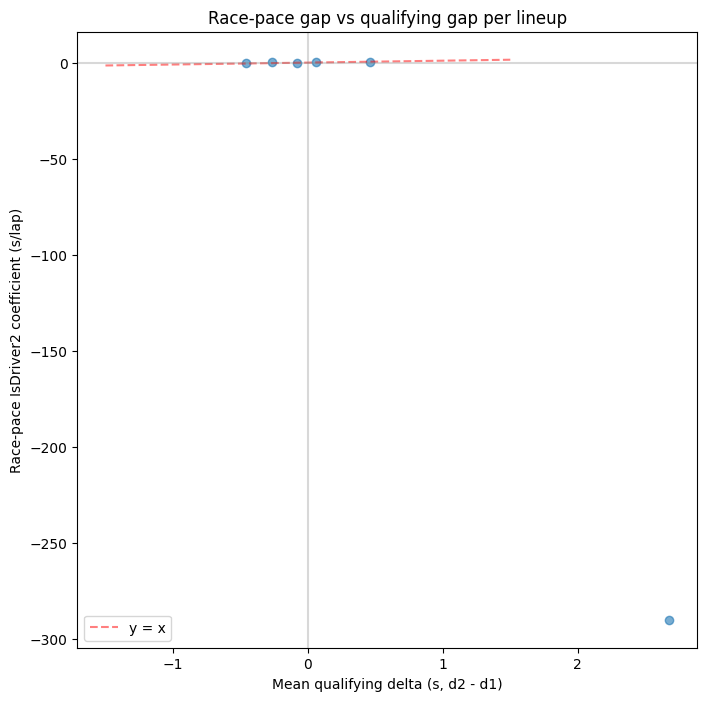

In [64]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(combined_quali_race["mean_delta_sec"], combined_quali_race["race_gap"], alpha=0.6)
ax.plot([-1.5, 1.5], [-1.5, 1.5], 'r--', alpha=0.5, label="y = x")
ax.axhline(0, color='gray', alpha=0.3)
ax.axvline(0, color='gray', alpha=0.3)
ax.set_xlabel("Mean qualifying delta (s, d2 - d1)")
ax.set_ylabel("Race-pace IsDriver2 coefficient (s/lap)")
ax.set_title("Race-pace gap vs qualifying gap per lineup")
ax.legend()
plt.savefig("../images/quali_vs_race.png", dpi=150)
plt.show()

In [63]:
print(combined_quali_race.sort_values("race_gap").head(3))

                lineup_id Driver1 Driver2  n_races  mean_delta_sec  \
5       Toro Rosso_2018_A     GAS     HAR        5        2.676800   
2         Mercedes_2018_A     BOT     HAM       17       -0.079412   
4  Red Bull Racing_2018_A     RIC     VER       13       -0.458462   

   median_delta_sec  mean_delta_pct  se_delta    t_stat   p_value  race_gap  \
5             0.492        2.466749  2.558600  1.046197  0.354523  -290.057   
2            -0.118       -0.062142  0.131279 -0.604909  0.553723    -0.308   
4            -0.273       -0.578117  0.189500 -2.419319  0.032358     0.003   

   race_se  race_n  race_minus_quali  concordant  
5    8.065       3       -292.733800       False  
2    0.059      12         -0.228588        True  
4    0.065       5          0.461462       False  


In [65]:
# Sanity bound: realistic race-pace gap is ±2 s/lap
combined_clean = combined_quali_race[combined_quali_race["race_gap"].abs() < 3].copy()
corr = combined_clean[["race_gap", "mean_delta_sec"]].corr().iloc[0, 1]
print(f"Correlation race vs quali gap: {corr:.3f}")
print(f"Concordance: {combined_clean['concordant'].mean()*100:.1f}%")

Correlation race vs quali gap: 0.655
Concordance: 60.0%


# Sector Analysis

In [76]:
def load_sector_data_for_team(year, team, schedules):
    schedule = schedules[year]
    all_laps = []
    
    for event in schedule["EventName"].tolist():
        try:
            session = fastf1.get_session(year, event, 'R')
            session.load(telemetry=False, weather=False, messages=False)
            
            laps = session.laps.pick_teams([team])[
                ["Driver", "Team", "LapTime", "LapNumber", "Stint", "Compound",
                 "TyreLife", "TrackStatus", "PitInTime", "PitOutTime",
                 "Sector1Time", "Sector2Time", "Sector3Time"]
            ].copy()
            
            laps = clean_laps_with_sectors(laps)
            if len(laps) == 0:
                continue
            
            laps["Year"] = year
            laps["Race"] = event
            laps["RaceID"] = f"{year}_{event}"
            all_laps.append(laps)
        except Exception as e:
            print(f"Failed {year} {event}: {e}")
            continue
    
    return pd.concat(all_laps, ignore_index=True) if all_laps else pd.DataFrame()

def clean_laps_with_sectors(df):
    """Same as clean_laps but also converts sector times."""
    df = df.copy()
    df["LapTime"] = df["LapTime"].dt.total_seconds()
    for sec in ["Sector1Time", "Sector2Time", "Sector3Time"]:
        df[sec] = df[sec].dt.total_seconds()
    
    mask = (
        (df["LapNumber"] > 1)
        & (df["TrackStatus"] == "1")
        & (df["PitInTime"].isna())
        & (df["PitOutTime"].isna())
        & (df["LapTime"].notna())
        & (df["Sector1Time"].notna())
        & (df["Sector2Time"].notna())
        & (df["Sector3Time"].notna())
    )
    df = df[mask]
    
    if len(df) == 0:
        return df
    
    med = df["LapTime"].median()
    df = df[df["LapTime"] < 1.1 * med]
    return df

In [84]:
# Load all schedules once and save
schedules = {}
for year in range(2018, 2026):
    try:
        schedules[year] = fastf1.get_event_schedule(year, include_testing=False)
    except Exception as e:
        print(f"Failed schedule {year}: {e}")

# Save to disk so you never need to re-fetch
import pickle
with open("../data/schedules.pkl", "wb") as f:
    pickle.dump(schedules, f)

In [85]:
import pickle
import os

# Load schedules once if not already cached locally
SCHEDULES_FILE = "../data/schedules.pkl"
if os.path.exists(SCHEDULES_FILE):
    with open(SCHEDULES_FILE, "rb") as f:
        schedules = pickle.load(f)
    print(f"Loaded cached schedules for years: {sorted(schedules.keys())}")
else:
    schedules = {}
    for year in range(2018, 2026):
        try:
            schedules[year] = fastf1.get_event_schedule(year, include_testing=False)
            print(f"Fetched schedule {year}")
        except Exception as e:
            print(f"Failed schedule {year}: {e}")
    with open(SCHEDULES_FILE, "wb") as f:
        pickle.dump(schedules, f)

# Pick interesting lineups
mercedes_2019 = load_sector_data_for_team(2019, "Mercedes", schedules)         # HAM-BOT, big gap
red_bull_2024 = load_sector_data_for_team(2024, "Red Bull Racing", schedules)  # VER-PER, anchor case
aston_2024    = load_sector_data_for_team(2024, "Aston Martin", schedules)     # ALO-STR, favouritism prior
mercedes_2023 = load_sector_data_for_team(2023, "Mercedes", schedules)         # HAM-RUS, balanced

# Save
all_sector_data = pd.concat(
    [mercedes_2019, red_bull_2024, aston_2024, mercedes_2023],
    ignore_index=True,
)
all_sector_data.to_parquet("../data/sector_data.parquet")

print(f"\nTotal: {len(all_sector_data)} laps across {all_sector_data['lineup_id' if 'lineup_id' in all_sector_data.columns else 'Team'].nunique()} team-seasons")

Loaded cached schedules for years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/60702678.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laps["Year"] = year
/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/60702678.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laps["Race"] = event
/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/60702678.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va


Total: 8727 laps across 3 team-seasons


In [86]:
def fit_sector_model(df, sector_col):
    """Fit mixed model for one sector or lap time."""
    df = df.copy()
    df = df.dropna(subset=[sector_col, "TyreLife", "LapNumber", "Compound", "IsDriver2", "RaceID"])
    df = df.reset_index(drop=True)
    
    if len(df) < 50:
        return None
    
    try:
        formula = f"{sector_col} ~ TyreLife + LapNumber + C(Compound) + IsDriver2"
        model = smf.mixedlm(formula, data=df, groups=df["RaceID"]).fit()
        return model
    except Exception as e:
        print(f"Failed {sector_col}: {e}")
        return None


def sector_decomposition(laps_lineup, lineup_label):
    """Decompose the within-team gap by sector."""
    results = []
    for sector in ["Sector1Time", "Sector2Time", "Sector3Time", "LapTime"]:
        model = fit_sector_model(laps_lineup, sector)
        if model is None:
            continue
        coef = model.params["IsDriver2"]
        se = model.bse["IsDriver2"]
        results.append({
            "lineup": lineup_label,
            "metric": sector,
            "coef": round(coef, 3),
            "se": round(se, 3),
            "ci_lower": round(coef - 1.96 * se, 3),
            "ci_upper": round(coef + 1.96 * se, 3),
            "p_value": model.pvalues["IsDriver2"],
        })
    
    df = pd.DataFrame(results)
    
    # Sanity check: sectors should sum to lap time
    sector_sum = df[df["metric"].isin(["Sector1Time", "Sector2Time", "Sector3Time"])]["coef"].sum()
    lap_total = df[df["metric"] == "LapTime"]["coef"].iloc[0] if "LapTime" in df["metric"].values else None
    print(f"{lineup_label}: sectors sum = {sector_sum:.3f}, lap total = {lap_total:.3f}")
    
    return df


# Process each lineup
all_sector_data = build_lineups(all_sector_data)
all_sector_data = assign_driver_indicator(all_sector_data)

sector_results = []
for lineup_id, lineup_df in all_sector_data.groupby("lineup_id"):
    if lineup_df["Driver"].nunique() < 2:
        continue
    result = sector_decomposition(lineup_df, lineup_id)
    sector_results.append(result)

sector_results = pd.concat(sector_results, ignore_index=True)
print(sector_results.to_string(index=False))

/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Team", "Year"], group_keys=False).apply(assign_phases)
/var/folders/02/djryd_w91q7ddr4lr1d9w_2w0000gn/T/ipykernel_22363/138209288.py:157: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lineup_id", group_keys=False).apply(_assign)


Aston Martin_2024_A: sectors sum = 0.249, lap total = 0.249
Aston Martin_2024_C: sectors sum = 0.301, lap total = 0.301


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

Mercedes_2019_A: sectors sum = -0.203, lap total = -0.202
Mercedes_2023_A: sectors sum = 0.155, lap total = 0.155
Mercedes_2023_C: sectors sum = 0.041, lap total = 0.041
Red Bull Racing_2024_B: sectors sum = -0.584, lap total = -0.583
Red Bull Racing_2024_D: sectors sum = -0.842, lap total = -0.842
                lineup      metric   coef    se  ci_lower  ci_upper      p_value
   Aston Martin_2024_A Sector1Time  0.083 0.018     0.048     0.118 3.554578e-06
   Aston Martin_2024_A Sector2Time  0.088 0.020     0.050     0.127 6.336294e-06
   Aston Martin_2024_A Sector3Time  0.078 0.015     0.049     0.106 9.642868e-08
   Aston Martin_2024_A     LapTime  0.249 0.042     0.167     0.331 2.291379e-09
   Aston Martin_2024_C Sector1Time  0.158 0.052     0.056     0.260 2.446150e-03
   Aston Martin_2024_C Sector2Time  0.119 0.090    -0.057     0.294 1.852856e-01
   Aston Martin_2024_C Sector3Time  0.024 0.076    -0.125     0.173 7.512149e-01
   Aston Martin_2024_C     LapTime  0.301 0.157    -